In [2]:
import pandas as pd
import numpy as np

In [3]:
sales_data = pd.read_csv(r"C:\Users\USER\OneDrive\Desktop\Mariam_Work\ecommerce_dataset_+1m.csv")
sales_copy = sales_data.copy()

In [4]:
for cols in sales_copy:
    print(f"Column name : {cols:35} || type {str(sales_copy[cols].dtype):7} || missing values: {round(sales_copy[cols].isna().sum()/sales_copy.shape[0] *100,2)}%")

Column name : order_id                            || type str     || missing values: 0.0%
Column name : order_date                          || type str     || missing values: 0.0%
Column name : order_year                          || type int64   || missing values: 0.0%
Column name : order_month                         || type int64   || missing values: 0.0%
Column name : order_day                           || type int64   || missing values: 0.0%
Column name : order_hour                          || type int64   || missing values: 0.0%
Column name : order_minute                        || type int64   || missing values: 0.0%
Column name : order_second                        || type int64   || missing values: 0.0%
Column name : is_weekend                          || type str     || missing values: 0.0%
Column name : order_status                        || type str     || missing values: 0.0%
Column name : return_reason                       || type str     || missing values: 90.01%
Column n

In [5]:
# Quick Data Cleaning
sales_copy.drop(columns={'return_reason'}, inplace=True)
sales_copy['coupon_code'] = sales_copy['coupon_code'].fillna('No Coupon')
sales_copy['customer_feedback'] = sales_copy['customer_feedback'].fillna('No Feedback')
sales_copy['order_year'] = sales_copy['order_year'].astype(str)
sales_copy['order_date'] = pd.to_datetime(sales_copy['order_date'], format='mixed')
sales_copy['order_day'] = sales_copy['order_date'].dt.day_name()


month_dict = {1:'January', 2:'February', 3:'March', 4:'April', 5:'May', 6:'June', 7:'July', 8:'August', 9:'September', 10:'October', 11:'November', 12:'December'}
sales_copy['order_month'] = sales_copy['order_month'].apply(lambda x:month_dict[x])
day_dict = {1:'Sunday', 2:'Monday', 3:'Tuesday', 4:'Wednesday', 5:'Thursday', 6:'Friday', 7:'Saturday'}

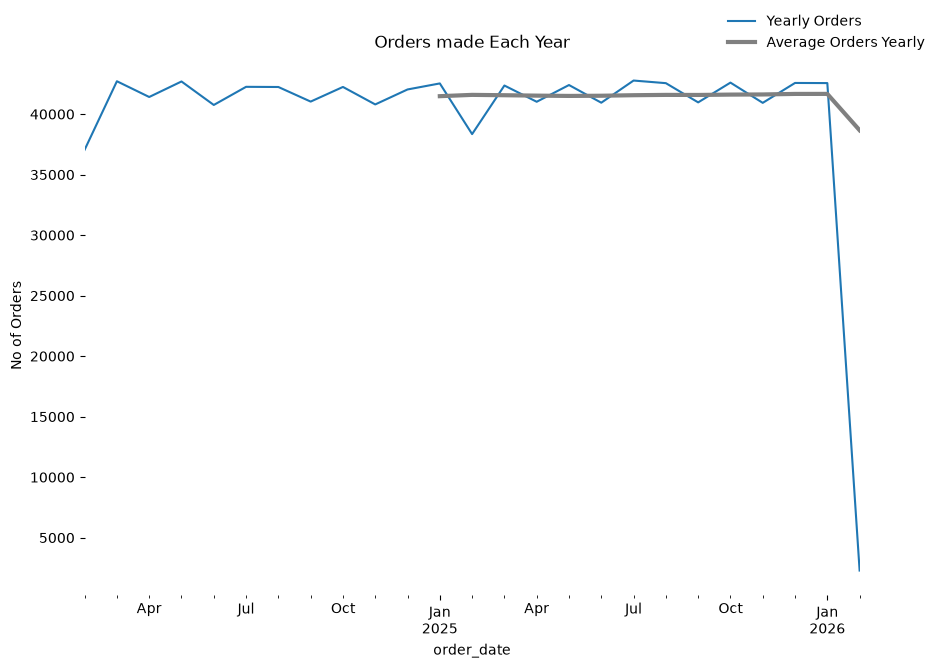

In [6]:
# Analysis 
# Trend of orders over the years
import seaborn as sns
import matplotlib.pylab as plt
fig,ax = plt.subplots(figsize = (10,7))
sales_copy.set_index('order_date').resample('ME').size().plot(ax =ax, label='Yearly Orders')
sales_copy.set_index('order_date').resample('ME').size().rolling(window=12).mean().plot(ax=ax, label='Average Orders Yearly', color = 'grey', linewidth =3)
ax.set_title('Orders made Each Year')
ax.set(ylabel ='No of Orders')
ax.legend(bbox_to_anchor = (1.1, 1.1), frameon= False)
sns.despine(ax = ax, top= True, bottom = True, left = True, right = True)


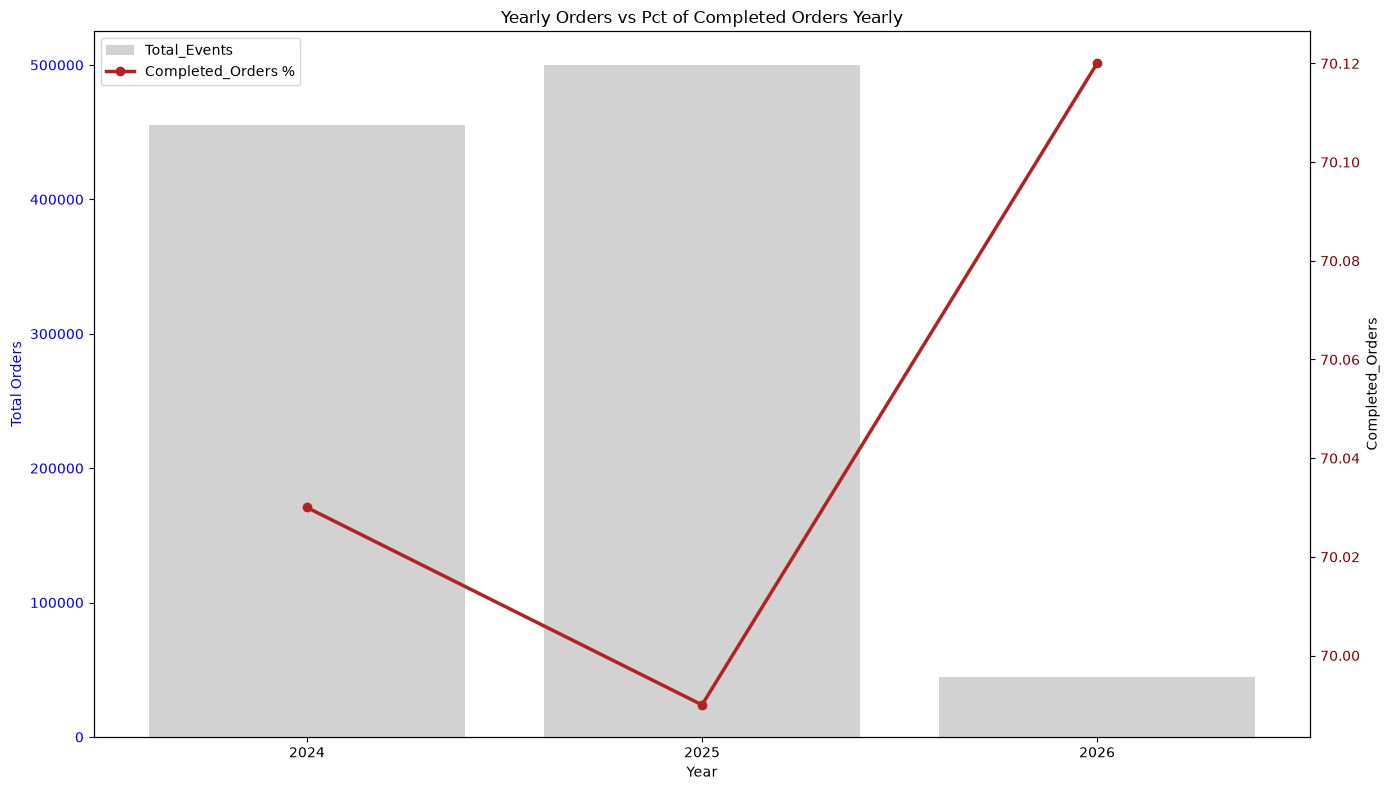

In [7]:
#  DISTRIBUTION OF ORDERS OVER THE YEARS
per_year = sales_copy.groupby('order_year').agg(
    Total_Orders = ('order_id','size'),
    Completed_Orders = ('order_status', lambda x: (x == 'Completed').sum())
).reset_index()
per_year['Completed_Order_Pct'] = (per_year['Completed_Orders'] / per_year['Total_Orders'] * 100).round(2)
fig, ax1 = plt.subplots(figsize = (14, 8))
ax1.bar(
    per_year['order_year'], 
    per_year['Total_Orders'],
    color = 'silver',
    alpha = 0.7,
    label = 'Total_Events'
)
ax1.set_ylabel('Total Orders', color= 'blue')
ax1.tick_params(axis = 'y', labelcolor = 'blue')
ax1.set_xlabel('Year')

ax2 = ax1.twinx()
ax2.plot(
    per_year['order_year'],
    per_year['Completed_Order_Pct'],
    color = 'firebrick',
    marker = 'o',
    linewidth = 2.5,
    label = 'Completed_Orders %'
)
ax2.set_ylabel('Completed_Orders')
ax2.tick_params(axis='y', labelcolor='darkred')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Yearly Orders vs Pct of Completed Orders Yearly')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [8]:
per_month = sales_copy.groupby('order_month').agg(
    Total_Orders = ('order_id', 'size'),
    Completed_Orders = ('order_status', lambda x: (x == 'Completed').sum())
).reset_index()
month =['January','February','March','April','May','June','July','August','September','October','November','December']
per_month['Completed_Orders_Pct'] = (per_month['Completed_Orders']/ per_month['Total_Orders'] *100).round(2)
per_month.index = pd.CategoricalIndex(per_month['order_month'], categories = month, ordered = True)
per_month = per_month.sort_index().reset_index(drop=True)
per_month

,order_month,Total_Orders,Completed_Orders,Completed_Orders_Pct
0,January,85100,59588,70.02
1,February,77685,54032,69.55
2,March,85079,59659,70.12
3,April,82436,57963,70.31
4,May,85100,59527,69.95
5,June,81699,57230,70.05
6,July,85029,59552,70.04
7,August,84799,59516,70.18
8,September,82005,57463,70.07
9,October,84848,59354,69.95


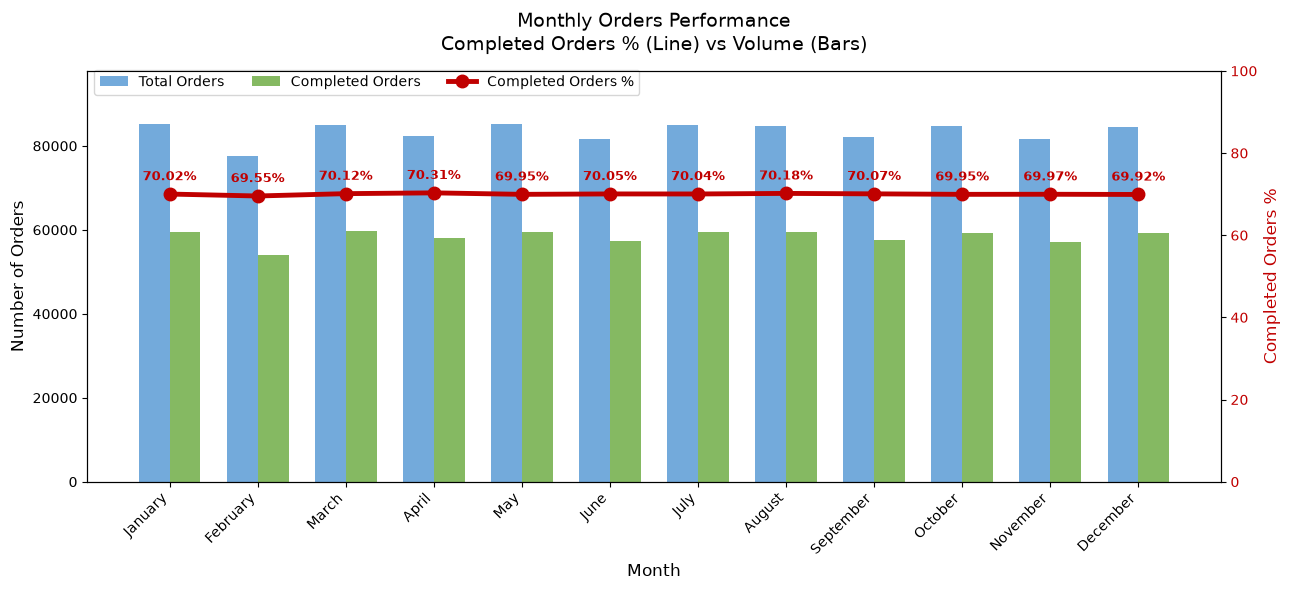

In [9]:
fig, ax1 = plt.subplots(figsize=(13, 6))

x = range(len(per_month))
width = 0.35

bars1 = ax1.bar(
    [i - width/2 for i in x],
    per_month['Total_Orders'],
    width,
    label='Total Orders',
    color='#5B9BD5',
    alpha=0.85
)

bars2 = ax1.bar(
    [i + width/2 for i in x],
    per_month['Completed_Orders'],
    width,
    label='Completed Orders',
    color='#70AD47',
    alpha=0.85
)

ax1.set_ylabel('Number of Orders', fontsize=12)
ax1.set_xlabel('Month', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(per_month['order_month'], rotation=45, ha='right')
ax1.set_ylim(0, per_month['Total_Orders'].max() * 1.15)

# ---- Prominent Line for Completed_Orders_Pct ----
ax2 = ax1.twinx()

line = ax2.plot(
    x,
    per_month['Completed_Orders_Pct'],
    color='#C00000',         
    marker='o',
    markersize=9,
    linewidth=3.5,           
    label='Completed Orders %',
    zorder=5
)

ax2.set_ylabel('Completed Orders %', fontsize=12, color='#C00000')
ax2.tick_params(axis='y', labelcolor='#C00000')
ax2.set_ylim(0, 100)          
# Add percentage values on the line
for i, pct in enumerate(per_month['Completed_Orders_Pct']):
    ax2.annotate(
        f'{pct}%',
        (i, pct),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='#C00000'
    )

# Title and combined legend
plt.title('Monthly Orders Performance\nCompleted Orders % (Line) vs Volume (Bars)', 
          fontsize=14, pad=15)

# Combine legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, 
           loc='upper left', bbox_to_anchor=(0, 1.02), ncol=3)

plt.tight_layout()
plt.show()

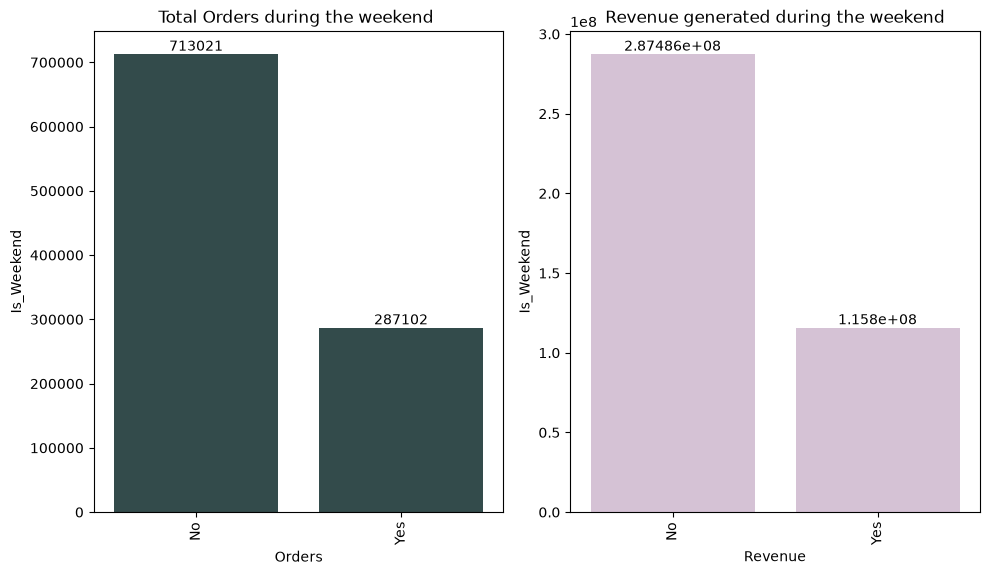

In [10]:
# Comparison of orders during weekdays and weekends 
weekend_sales_orders = sales_copy.groupby('is_weekend').agg(
    Total_Orders = ('order_id' , 'size'),
    Revenue = ('total_price_usd', 'sum')
    ).reset_index()
fig, ax = plt.subplots(1,2, figsize = (10,6))
sns.barplot(data = weekend_sales_orders, y=  'Total_Orders', x = 'is_weekend', color = 'darkslategrey', ax = ax[0])
sns.barplot(data = weekend_sales_orders, y= 'Revenue', x = 'is_weekend', color='thistle', ax = ax[1])
ax[0].set_title('Total Orders during the weekend ')
ax[1].set_title('Revenue generated during the weekend')
ax[0].set(xlabel = 'Orders', ylabel ='Is_Weekend')
ax[1].set(xlabel = 'Revenue', ylabel = 'Is_Weekend')
for axes in ax:
    axes.tick_params(axis='x', rotation = 90.5)
    for bars in axes.containers:
        axes.bar_label(bars, label_type='edge')
plt.tight_layout()
plt.show()


In [11]:
# Average revenue and orders generated per week
sales_copy['Is_Completed'] = (sales_copy['order_status'] == 'Completed').astype(int)
orders_per_week = sales_copy.set_index('order_date').resample('1D').agg(Total_Orders=('order_id', 'count'), Completed_Orders = ('Is_Completed', 'sum')).reset_index()
orders_per_week['Day'] = orders_per_week['order_date'].dt.day_name()
avg_orders_weekly =orders_per_week.groupby('Day')[['Total_Orders', 'Completed_Orders']].mean().reset_index()
avg_orders_weekly['Success Rate (%)'] = (avg_orders_weekly['Completed_Orders'] / avg_orders_weekly['Total_Orders']) * 100
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_orders_weekly['Day'] = pd.Categorical(avg_orders_weekly['Day'], categories=day_order, ordered=True)
avg_orders_weekly = avg_orders_weekly.sort_values('Day').reset_index(drop = True)
print(avg_orders_weekly)

         Day  Total_Orders  Completed_Orders  Success Rate (%)
0     Monday   1365.523810        957.000000         70.082996
1    Tuesday   1373.788462        963.201923         70.112827
2  Wednesday   1368.278846        957.240385         69.959452
3   Thursday   1365.865385        956.894231         70.057726
4     Friday   1369.384615        959.980769         70.103078
5   Saturday   1367.028571        956.457143         69.966141
6     Sunday   1367.276190        954.647619         69.821125


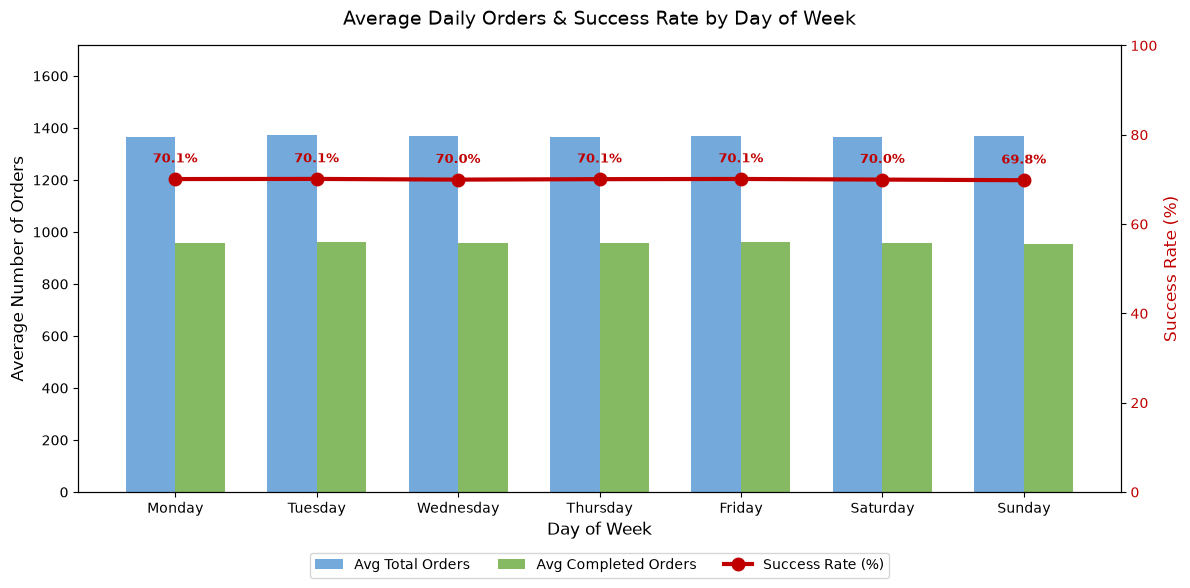

In [12]:
fig, ax1 = plt.subplots(figsize=(12, 6))

x = np.arange(len(avg_orders_weekly))
width = 0.35

# Bars for Total Orders and Completed Orders
bars1 = ax1.bar(x - width/2, avg_orders_weekly['Total_Orders'], width,
                label='Avg Total Orders', color='#5B9BD5', alpha=0.85)
bars2 = ax1.bar(x + width/2, avg_orders_weekly['Completed_Orders'], width,
                label='Avg Completed Orders', color='#70AD47', alpha=0.85)

ax1.set_ylabel('Average Number of Orders', fontsize=12)
ax1.set_xlabel('Day of Week', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(avg_orders_weekly['Day'], rotation=0)
ax1.set_ylim(0, avg_orders_weekly['Total_Orders'].max() * 1.25)

# Line for Success Rate on secondary axis
ax2 = ax1.twinx()
line = ax2.plot(x, avg_orders_weekly['Success Rate (%)'],
                color='#C00000', marker='o', markersize=9,
                linewidth=3, label='Success Rate (%)')

ax2.set_ylabel('Success Rate (%)', fontsize=12, color='#C00000')
ax2.tick_params(axis='y', labelcolor='#C00000')
ax2.set_ylim(0, 100)

# Add percentage labels on the line
for i, pct in enumerate(avg_orders_weekly['Success Rate (%)']):
    ax2.annotate(f'{pct:.1f}%',
                 (i, pct),
                 textcoords="offset points",
                 xytext=(0, 12),
                 ha='center',
                 fontsize=9,
                 fontweight='bold',
                 color='#C00000')

# Title and combined legend
plt.title('Average Daily Orders & Success Rate by Day of Week', fontsize=14, pad=15)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3)

plt.tight_layout()
plt.show()

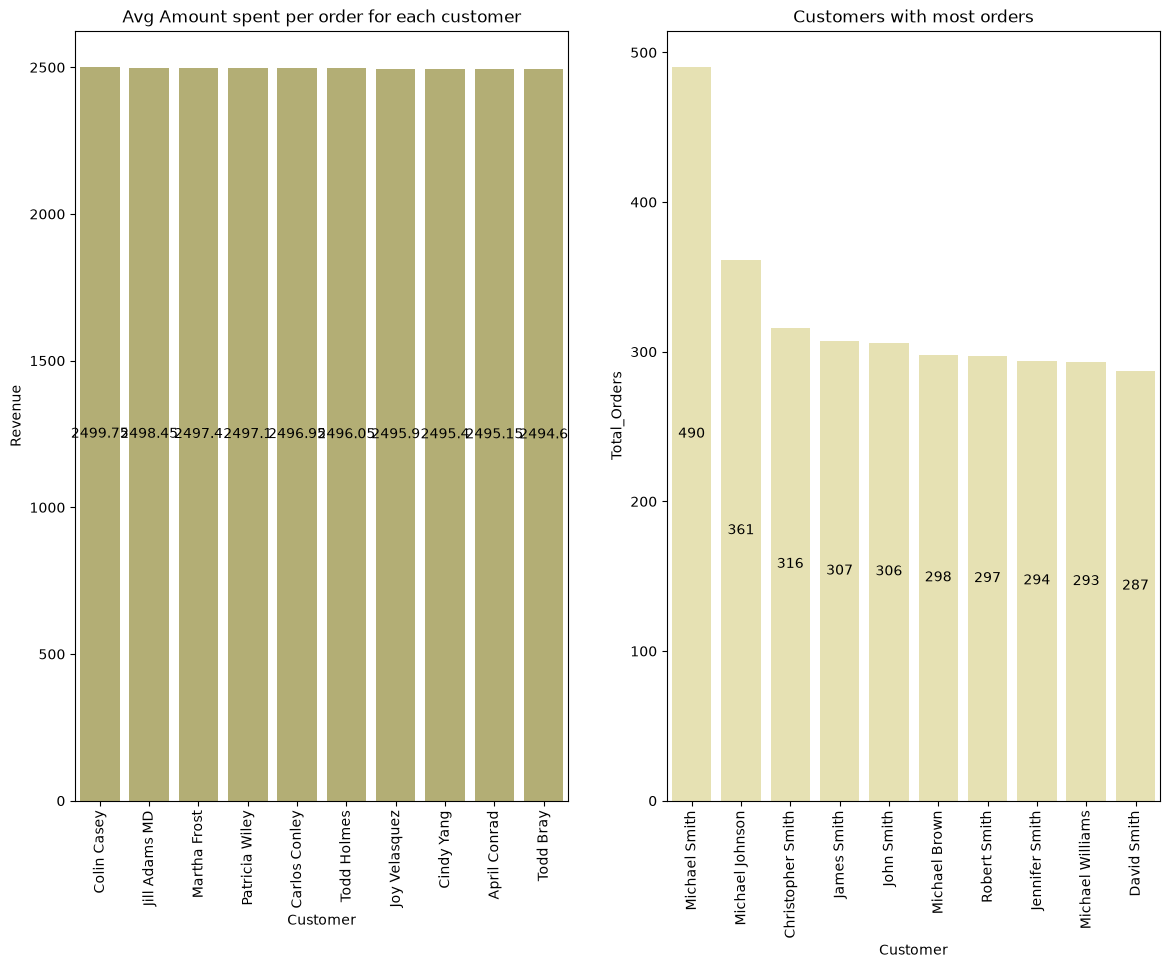

In [13]:
# Customers with the most orders, average amount per order per customer
order_totals = sales_copy.groupby(['customer_name', 'order_id'])['total_price_usd'].sum().reset_index()
avg_per_customer =order_totals.groupby('customer_name')['total_price_usd'].mean().reset_index(name='Revenue').sort_values(by='Revenue', ascending=False)
custo_orders = sales_copy.groupby('customer_name')['order_id'].size().reset_index(name='Total_Orders').sort_values(by='Total_Orders', ascending=False)
fig, ax = plt.subplots(1,2,figsize = (14, 10))
sns.barplot(data = avg_per_customer.head(10), x = 'customer_name', y='Revenue', color='darkkhaki', ax=ax[0])
sns.barplot(data = custo_orders.head(10), x ='customer_name', y='Total_Orders', color= 'palegoldenrod', ax=ax[1])
ax[0].set_title("Avg Amount spent per order for each customer")
ax[1].set_title("Customers with most orders")
ax[0].set(xlabel = 'Customer', ylabel = 'Revenue')
ax[1].set(xlabel = 'Customer', ylabel='Total_Orders')
for axes in ax:
    axes.tick_params(axis='x', rotation = 90.5)
    for bars in axes.containers:
        axes.bar_label(bars, label_type='center')
plt.show()

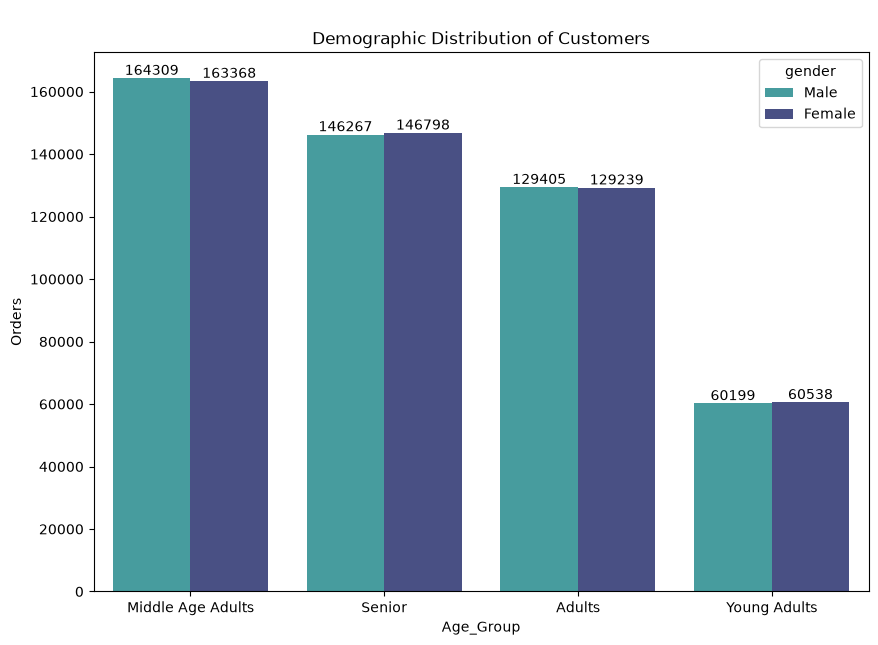

In [14]:
# Demographic of customers 
def age_category(age):
    
    if age >= 18 and age < 25:
        return "Young Adults"
    elif age >= 25 and age < 40:
        return "Adults"
    elif age >= 40 and age < 59:
        return "Middle Age Adults"
    else:
        return "Senior"
sales_copy['age_group'] = sales_copy['age'].apply(age_category)
demo_distr = sales_copy.groupby(['age_group', 'gender'])['order_id'].size().reset_index(name = 'Total_Orders').sort_values(by = 'Total_Orders', ascending=False)
fig, ax = plt.subplots(figsize = (10,7))
sns.barplot(data=demo_distr, x = 'age_group', y = 'Total_Orders', hue='gender', palette='mako_r', ax=ax)
ax.set_title("\nDemographic Distribution of Customers")
ax.set(xlabel = 'Age_Group', ylabel = 'Orders')
for bars in ax.containers:
    ax.bar_label(bars, label_type='edge')

In [15]:
# Product Analysis
# Product with most orders and revenue generated
product_volume_revenue = sales_copy.groupby('product_name').agg(
    Total_Orders = ('order_id', 'size'),
    Revenue = ('total_price_usd', 'sum')
).reset_index().sort_values(['Total_Orders', 'Revenue'], ascending=False)

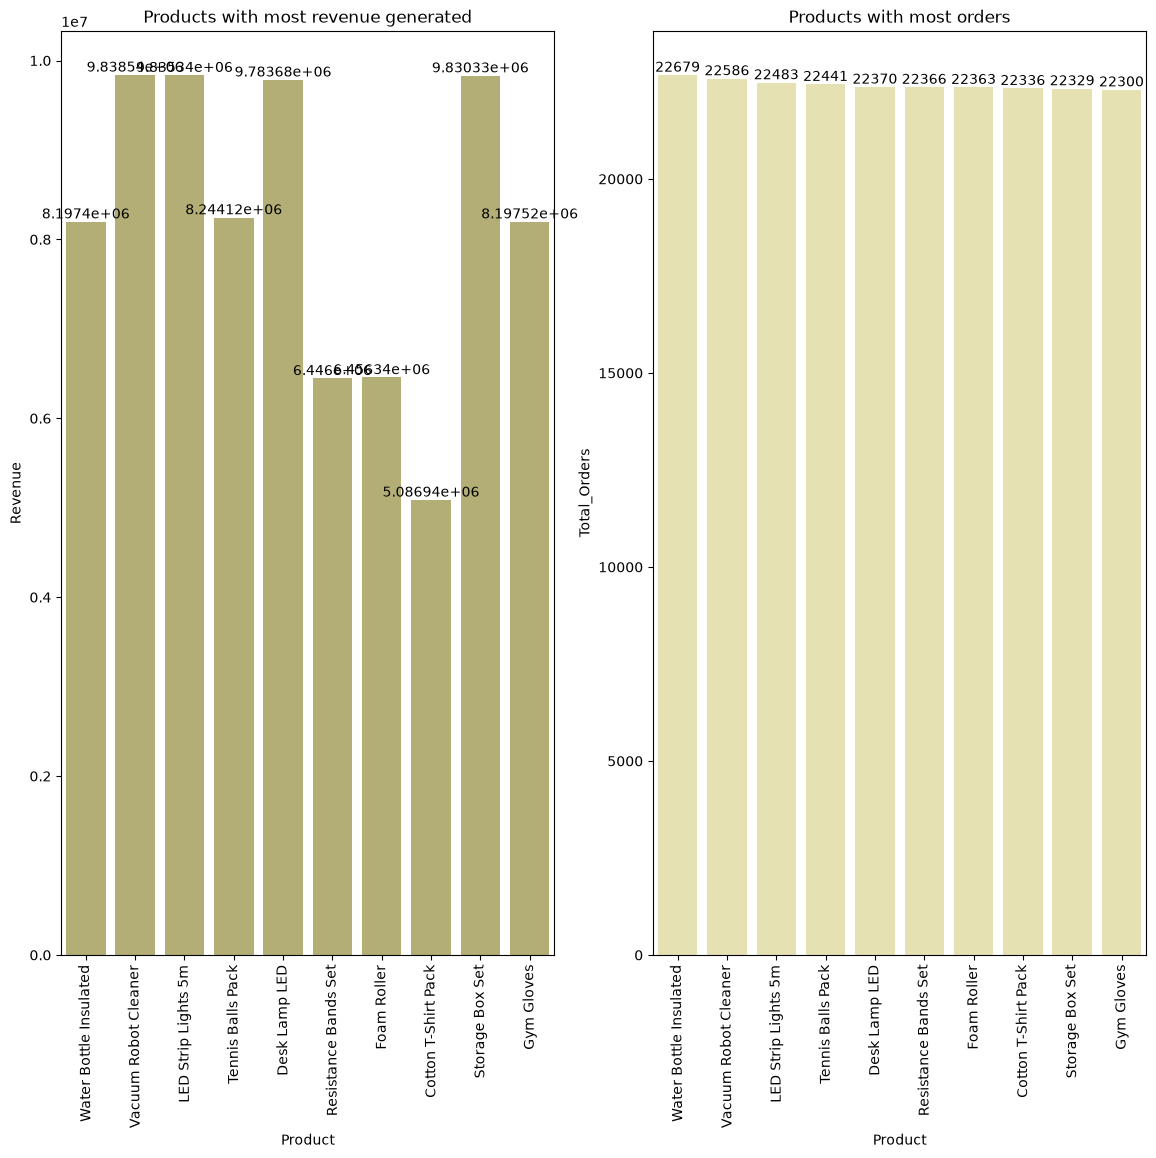

In [16]:
fig, ax = plt.subplots(1,2, figsize = (14,12))
sns.barplot(data = product_volume_revenue.head(10), x = 'product_name', y='Revenue', color='darkkhaki', ax=ax[0])
sns.barplot(data = product_volume_revenue.head(10), x ='product_name', y='Total_Orders', color= 'palegoldenrod', ax=ax[1])
ax[0].set_title("Products with most revenue generated")
ax[1].set_title("Products with most orders")
ax[0].set(xlabel = 'Product', ylabel = 'Revenue')
ax[1].set(xlabel = 'Product', ylabel='Total_Orders')
for axes in ax:
    axes.tick_params(axis='x', rotation = 90.5)
    for bars in axes.containers:
        axes.bar_label(bars, label_type='edge')
plt.show()

In [17]:
# Products that are dead stock
from datetime import datetime, timedelta
end_date = sales_copy['order_date'].max()
start_date = end_date - timedelta(days=90)

recent_sales =sales_copy[(sales_copy['order_date'] >= start_date) & (sales_copy['order_date'] < end_date)]
recent_sales_agg = recent_sales.groupby('product_id', as_index =False)['quantity'].sum()
merged_df = pd.merge(sales_copy, recent_sales_agg, on='product_id', how='left')
merged_df.columns
merged_df['quantity_y'] = merged_df['quantity_y'].fillna(0)

dead_stock_df = merged_df[merged_df['quantity_y'] <= 0].copy()
dead_stock_df['dead_stock_value'] = dead_stock_df['stock_quantity'] *  dead_stock_df['unit_price_usd']

print(f"Dead stock analysis based on sales from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}:\n")
print(dead_stock_df[['product_id', 'stock_quantity', 'unit_price_usd', 'dead_stock_value']])

Dead stock analysis based on sales from 2025-11-04 to 2026-02-02:

        product_id  stock_quantity  unit_price_usd  dead_stock_value
0         PRD-1FPK              99          120.51          11930.49
1         PRD-C6UZ             146           60.33           8808.18
3         PRD-IROD             884          186.33         164715.72
4         PRD-LBR7              82          427.16          35027.12
5         PRD-60FK             517          156.79          81060.43
...            ...             ...             ...               ...
1000118   PRD-PHM3             551          193.50         106618.50
1000119   PRD-T0M6             218           27.80           6060.40
1000120   PRD-OAN2            1000          180.63         180630.00
1000121   PRD-71G1             303           33.92          10277.76
1000122   PRD-NBP2             543          139.44          75715.92

[814309 rows x 4 columns]


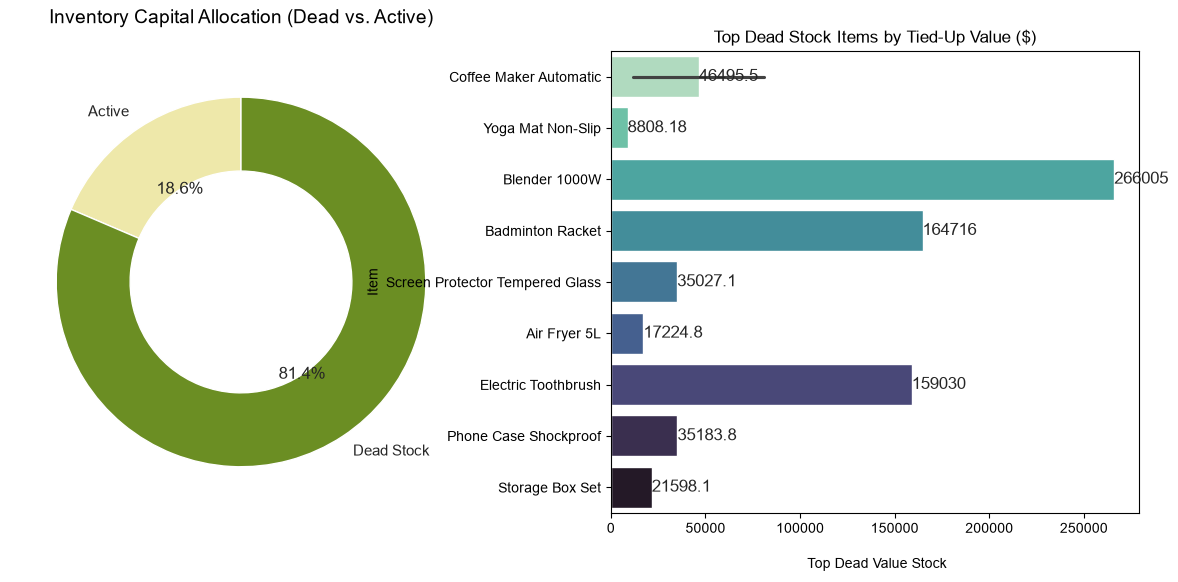

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.set_theme(style="whitegrid")
merged_df['total_value'] = merged_df['stock_quantity'] * merged_df['unit_price_usd']
merged_df['product_status'] = merged_df['quantity_y'].apply(lambda x: 'Dead Stock' if x == 0 else 'Active')
dead_stock = merged_df[merged_df['product_status'] == 'Dead Stock'].sort_values(by='total_value', ascending=False)
cap_breakdown = merged_df.groupby('product_status')['total_value'].sum()
axes[0].pie(cap_breakdown, labels=cap_breakdown.index, autopct='%1.1f%%', 
            startangle=90, colors=['palegoldenrod', 'olivedrab'], wedgeprops=dict(width=0.4))
axes[0].set_title('Inventory Capital Allocation (Dead vs. Active)', fontsize=14, pad=20)
sns.barplot(x = 'total_value', y = 'product_name', data= merged_df.head(10),hue= 'product_name',ax = axes[1],palette='mako_r')
axes[1].set_title('\nTop Dead Stock Items by Tied-Up Value ($)')
axes[1].set(xlabel ='\n Top Dead Value Stock', ylabel = 'Item')
for bars in axes[1].containers:
    axes[1].bar_label(bars, label_type='edge')

In [19]:
# Most sold product each month
most_sold_month = sales_copy.groupby(['order_year','order_month', 'product_name'])['quantity'].sum().reset_index(name = 'quantity_sold').sort_values(by='quantity_sold', ascending=False)
idx = most_sold_month.groupby(['order_year','order_month'])['quantity_sold'].idxmax()
most_sold_each_month = most_sold_month.loc[idx]
most_sold_each_month
most_sold_each_month['order_month'] = pd.Categorical(most_sold_each_month['order_month'], categories=month, ordered=True)
most_sold_each_month = most_sold_each_month.sort_values(['order_year', 'order_month'])
table = (most_sold_each_month
         .sort_values(['order_year', 'order_month'])
         .reset_index(drop=True)
         [['order_year', 'order_month', 'product_name', 'quantity_sold']]
         .rename(columns={
             'order_year': 'Year',
             'order_month': 'Month',
             'product_name': 'Top Product',
             'quantity_sold': 'Quantity Sold'
         }))

# Display with nice formatting
styled_table = (table.style
    .format({'Quantity Sold': '{:,.0f}'})
    .set_caption("Most Sold Product by Year & Month")
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#2F5496'), ('color', 'white'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'left')]},
    ])
    .background_gradient(subset=['Quantity Sold'], cmap='Blues')
)

styled_table

,Year,Month,Top Product,Quantity Sold
0,2024,February,Baseball Cap,"2,674"
1,2024,March,Jump Rope Speed,"3,137"
2,2024,April,LED Strip Lights 5m,"2,951"
3,2024,May,Hooded Sweatshirt,"3,127"
4,2024,June,Fitness Smart Band,"2,933"
5,2024,July,Vacuum Robot Cleaner,"3,028"
6,2024,August,Denim Jeans Slim Fit,"3,015"
7,2024,September,Tennis Balls Pack,"2,982"
8,2024,October,Foam Roller,"2,992"
9,2024,November,Air Fryer 5L,"2,924"


In [20]:
# RFM Segmentation
# Recency
recent_sales_df = sales_copy.groupby(by ='customer_id', as_index=False)['order_date'].max()
recent_sales_df.columns = ['Customer_ID', 'LastPurchaseDate' ]
recent_date = recent_sales_df['LastPurchaseDate'].max()
recent_sales_df['Recency'] = recent_sales_df['LastPurchaseDate'].apply(lambda x:(recent_date - x).days)

# Frequency
frequency_sales_df = sales_copy.drop_duplicates().groupby(by='customer_id', as_index=False)['order_date'].count()
frequency_sales_df.columns = ['Customer_ID', 'Frequency']

# Monetary
sales_copy['Total'] = sales_copy['total_price_usd']  # Total spent by each customer
revenue_sales_df = sales_copy.groupby(by='customer_id', as_index=False)['Total'].sum()
revenue_sales_df.columns = ['Customer_ID', 'Monetary']

# merging recency, frequency and monetary
rf_df = recent_sales_df.merge(frequency_sales_df, on='Customer_ID')
rfm_df = rf_df.merge(revenue_sales_df, on = 'Customer_ID').drop(columns='LastPurchaseDate')
rfm_df

,Customer_ID,Recency,Frequency,Monetary
0,CUS-0000E,477,1,129.58
1,CUS-0000G,536,1,41.06
2,CUS-00043,726,1,131.85
3,CUS-0005H,408,1,599.50
4,CUS-0005M,587,1,497.21
...,...,...,...,...
991940,CUS-ZZZPI,91,1,36.86
991941,CUS-ZZZQE,62,1,375.21
991942,CUS-ZZZR0,325,1,299.23
991943,CUS-ZZZX5,194,1,352.20


In [21]:
# Ranking Customers based on Recency, Frequency and Monetary
rfm_df['R_rank'] = rfm_df['Recency'].rank(ascending=False)
rfm_df['F_rank'] = rfm_df['Frequency'].rank(ascending=True)
rfm_df['M_rank'] = rfm_df['Monetary'].rank(ascending=True)

# Normalizing the ranks
rfm_df['R_rank_norm'] = (rfm_df['R_rank'] / rfm_df['R_rank'].max()) * 100
rfm_df['F_rank_norm'] = (rfm_df['F_rank'] / rfm_df['F_rank'].max()) * 100
rfm_df['M_rank_norm'] = (rfm_df['M_rank'] / rfm_df['M_rank'].max()) * 100

# dropping inviduals ranks
rfm_df.drop(columns={'R_rank', 'F_rank', 'M_rank'}, inplace=True)
rfm_df.head()


,Customer_ID,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm
0,CUS-0000E,477,1,129.58,34.501907,49.5915,22.815025
1,CUS-0000G,536,1,41.06,26.471717,49.5915,3.796279
2,CUS-00043,726,1,131.85,0.540471,49.5915,23.291362
3,CUS-0005H,408,1,599.50,43.859491,49.5915,78.134322
4,CUS-0005M,587,1,497.21,19.531246,49.5915,71.192758


In [22]:
rfm_df['RFM_Score'] = 0.15 * rfm_df['R_rank_norm'] + 0.28 * rfm_df['F_rank_norm'] + 0.57 * rfm_df['M_rank_norm']
rfm_df['RFM_Score'] *= 0.05
rfm_df = rfm_df.round(2)

rfm_df[['Customer_ID', 'RFM_Score']].head(7)

,Customer_ID,RFM_Score
0,CUS-0000E,1.60
1,CUS-0000G,1.00
2,CUS-00043,1.36
3,CUS-0005H,3.25
4,CUS-0005M,2.87
5,CUS-0005N,2.21
6,CUS-00065,0.90


In [23]:
rfm_df["Customer_Segment"] = np.where(rfm_df['RFM_Score'] > 4.5, "Top Customers", np.where(rfm_df['RFM_Score'] > 4, "High Value Customer", np.where(rfm_df['RFM_Score'] > 3, "Medium Value Customer", np.where(rfm_df['RFM_Score']> 1.6, "Low Value Customers", 'Lost Cutomers'))))
rfm_df[['Customer_ID', 'RFM_Score', 'Customer_Segment']].head(10)

,Customer_ID,RFM_Score,Customer_Segment
0,CUS-0000E,1.60,Lost Cutomers
1,CUS-0000G,1.00,Lost Cutomers
2,CUS-00043,1.36,Lost Cutomers
3,CUS-0005H,3.25,Medium Value Customer
4,CUS-0005M,2.87,Low Value Customers
5,CUS-0005N,2.21,Low Value Customers
6,CUS-00065,0.90,Lost Cutomers
7,CUS-00086,1.59,Lost Cutomers
8,CUS-000A9,2.24,Low Value Customers
9,CUS-000AF,3.34,Medium Value Customer


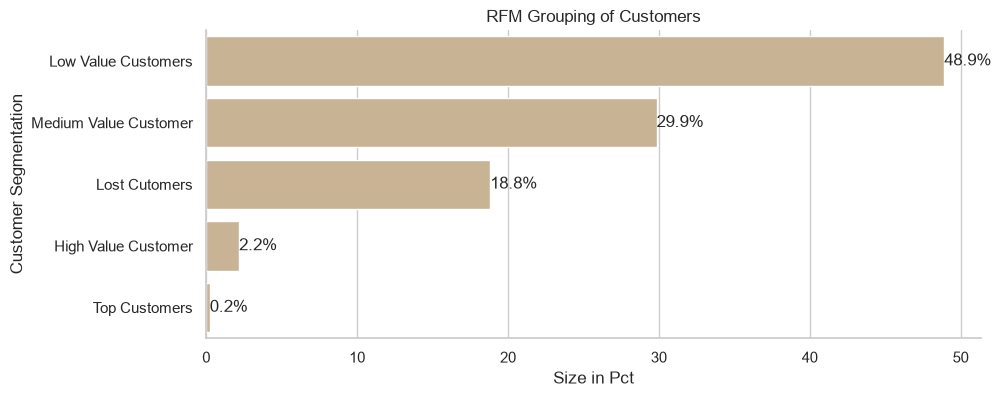

In [24]:
rfm_groups = rfm_df.groupby('Customer_Segment')['Customer_ID'].size().reset_index(name = 'Size').sort_values(by = 'Size', ascending = False)
rfm_groups['Pct'] = (rfm_groups['Size'] / rfm_groups['Size'].sum())*100
fig,ax = plt.subplots(figsize = (10, 4))
sns.barplot(data = rfm_groups, y = 'Customer_Segment',x='Pct', color='tan', ax = ax)
ax.set_title('RFM Grouping of Customers')
ax.set(ylabel = 'Customer Segmentation', xlabel = 'Size in Pct')
for bars in ax.containers:
    ax.bar_label(bars,fmt='%.1f%%', label_type='edge')
sns.despine()
plt.show()


In [25]:
profit_margin = sales_copy['profit_margin_percent'].mean()
profit_margin = profit_margin / 100
profit_margin

np.float64(0.3946517022406244)

In [26]:
total_revenue = sales_copy['total_price_usd'].sum()
total_orders = sales_copy['order_id'].nunique()
total_customers = sales_copy['customer_id'].nunique()


aov = total_revenue / total_orders
purchase_frequency = total_orders / total_customers

order_counts = sales_copy.groupby('customer_id')['order_id'].count()
repeat_customers = max(1, (order_counts > 1).sum())
repeat_rate = repeat_customers / total_customers
churn_rate = 1 - repeat_rate

if churn_rate == 0:
    churn_rate = 0.01

aggregate_clv = (aov * purchase_frequency) / churn_rate * profit_margin
print(f"Average Order Value: ${aov:.2f}")
print(f"Purchase Frequency: {purchase_frequency:.2f}")
print(f"Churn Rate: {churn_rate * 100:.1f}%")
print(f"--- Business Average CLV: ${aggregate_clv:.2f} ---")

Average Order Value: $406.57
Purchase Frequency: 1.00
Churn Rate: 99.2%
--- Business Average CLV: $161.78 ---


In [27]:
customer_df = sales_copy.groupby('customer_id').agg(
    total_revenue=('total_price_usd', 'sum'),
    total_orders=('order_id', 'count')
).reset_index()

# Calculate individual AOV
customer_df['aov'] = customer_df['total_revenue'] / customer_df['total_orders']

# Use the business-wide purchase frequency and churn rate to project future value
customer_df['historical_clv'] = (customer_df['aov'] * purchase_frequency) / churn_rate * profit_margin
customer_value = aov * purchase_frequency
average_lifespan_months = 12
cohort_clv = customer_value * average_lifespan_months

print(customer_df[['customer_id', 'total_revenue', 'historical_clv']])

       customer_id  total_revenue  historical_clv
0        CUS-0000E         129.58       51.560735
1        CUS-0000G          41.06       16.338044
2        CUS-00043         131.85       52.463983
3        CUS-0005H         599.50      238.544997
4        CUS-0005M         497.21      197.843132
...            ...            ...             ...
991940   CUS-ZZZPI          36.86       14.666837
991941   CUS-ZZZQE         375.21      149.298529
991942   CUS-ZZZR0         299.23      119.065587
991943   CUS-ZZZX5         352.20      140.142699
991944   CUS-ZZZZE         358.34      142.585845

[991945 rows x 3 columns]


C:\Users\USER\AppData\Local\Temp\ipykernel_23952\699357212.py:30: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


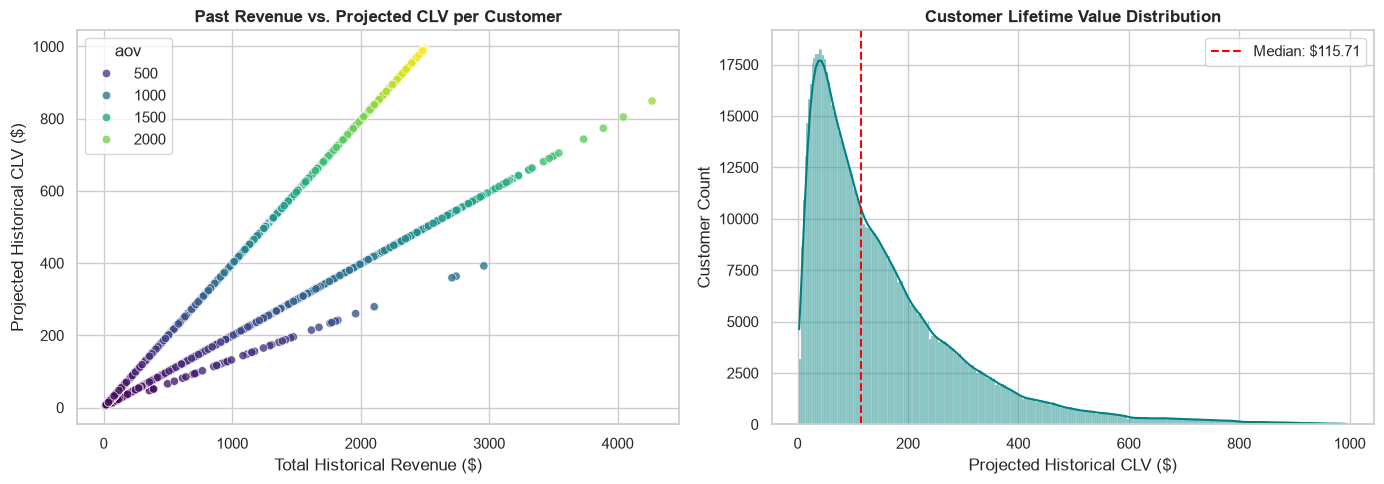

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Scatter plot comparing Historical Revenue vs. Projected CLV
sns.scatterplot(
    data=customer_df,
    x='total_revenue',
    y='historical_clv',
    hue='aov',
    palette='viridis',
    alpha=0.8,
    ax=axes[0]
)
axes[0].set_title('Past Revenue vs. Projected CLV per Customer', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Historical Revenue ($)')
axes[0].set_ylabel('Projected Historical CLV ($)')

# Plot 2: Distribution of Projected CLV
sns.histplot(
    customer_df['historical_clv'], 
    kde=True, 
    color='teal', 
    ax=axes[1]
)
axes[1].axvline(customer_df['historical_clv'].median(), color='red', linestyle='--', label=f"Median: ${customer_df['historical_clv'].median():.2f}")
axes[1].set_title('Customer Lifetime Value Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Projected Historical CLV ($)')
axes[1].set_ylabel('Customer Count')
axes[1].legend()

plt.tight_layout()
plt.show()
plt.show()

In [29]:
customer_df['historical_clv'].unique()

array([ 51.56073504,  16.3380443 ,  52.46398299, ..., 409.48566471,
       874.84139277, 625.13511652], shape=(143667,))